# 6. Explainable AI

In this notebook following the machine learning process in the previous we will try to focus on the genera that push our models in the previous notebook show the result they show.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from scipy.stats import kruskal
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings("ignore")

# Load data
meta = pd.read_csv("../data/processed/metadata_final.tsv", sep="\t", index_col="Sample")
genera_clr = pd.read_csv("../data/processed/genera_clr.tsv", sep="\t", index_col=0)
candidates = pd.read_csv("../data/processed/candidate_genera.csv")
meta = meta.loc[genera_clr.index]

# Rebuild CD vs nonIBD dataset
mask = meta["Study.Group"].isin(["CD", "nonIBD"])
meta_cd = meta[mask]
X_cd = genera_clr.loc[meta_cd.index]
y_cd = (meta_cd["Study.Group"] == "CD").astype(int)

print("CD vs nonIBD dataset:")
print(f"  CD: {(y_cd==1).sum()}, nonIBD: {(y_cd==0).sum()}")
print(f"  Features: {X_cd.shape[1]}")
print(f"  Gender candidates loaded: {len(candidates)}")

CD vs nonIBD dataset:
  CD: 49, nonIBD: 26
  Features: 2761
  Gender candidates loaded: 82


## Train the best model on full dataset with KW features

In [11]:
# Select top 100 genera by Kruskal-Wallis on full dataset
# Note: for SHAP interpretation we use the full dataset
# We are not evaluating performance here like before
# We are training for interpretation only

p_values = []
for col in X_cd.columns:
    group0 = X_cd[col][y_cd == 0].values
    group1 = X_cd[col][y_cd == 1].values
    stat, p = kruskal(group0, group1)
    p_values.append(p)

p_series = pd.Series(p_values, index=X_cd.columns)
top_features = p_series.nsmallest(100).index.tolist()

X_cd_sel = X_cd[top_features]

print(f"Top 100 genera selected for SHAP analysis")
print(f"Best KW p-value: {p_series.min():.4f}")
print(f"Feature matrix shape: {X_cd_sel.shape}")

# Train Logistic Regression on full dataset
model = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
model.fit(X_cd_sel, y_cd)

# Quick sanity check
from sklearn.metrics import roc_auc_score
y_prob = model.predict_proba(X_cd_sel)[:, 1]
print(f"\nTraining AUC (optimistic, full data): {roc_auc_score(y_cd, y_prob):.3f}")
print("(We use notebook 05 AUC=0.665 as the real performance estimate)")

Top 100 genera selected for SHAP analysis
Best KW p-value: 0.0007
Feature matrix shape: (75, 100)

Training AUC (optimistic, full data): 0.987
(We use notebook 05 AUC=0.665 as the real performance estimate)


## Compute SHAP values

SHAP assigns a number for each genus and subject pair that represents how much that genus pushes towards CD (or UC) or nonIBD. The mean absolute SHAP value across all subjects tells us overall feature importance, meaning which genera matter more to the analysis

In [12]:
# we use SHAP LinearExplainer
explainer = shap.LinearExplainer(model, X_cd_sel, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_cd_sel)

print(f"SHAP values shape: {shap_values.shape}")
print(f"  Rows = subjects ({shap_values.shape[0]})")
print(f"  Cols = genera ({shap_values.shape[1]})")
print(f"\nMean |SHAP| per feature (top 5):")

mean_shap = np.abs(shap_values).mean(axis=0)
shap_series = pd.Series(mean_shap, index=top_features)
print(shap_series.nlargest(5))

SHAP values shape: (75, 100)
  Rows = subjects (75)
  Cols = genera (100)

Mean |SHAP| per feature (top 5):
d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Anaerotignaceae;g__Anaerotignum                     0.374546
d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Peptostreptococcales;f__Peptostreptococcaceae;g__Romboutsia           0.366246
d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__CAG-272;g__Flemingibacterium                       0.301761
d__Bacteria;p__Desulfobacterota_I;c__Desulfovibrionia;o__Desulfovibrionales;f__Desulfovibrionaceae;g__Bilophila    0.285765
d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__CAG-272;g__UMGS902                                 0.199631
dtype: float64


## Beeswarm plot 

In the following plot each row is a genus. The x-axis explains the direction the genus pushes the prediction, with positive pushing towards CD and negative towards nonIBD. The color shows the real CLR abundance. For example a red dot on the right means high abundance of that genus equals a stronger CD prediction or a blue dot on the right low abundance means stronger CD prediction.

* Comment:

Most dots cluster near zero with a few subjects pulling far left or right — meaning for most patients these genera give weak signals, but for a subset they are very discriminative. This is why AUC is 0.665 and not 0.80 — the signal exists but is noisy.

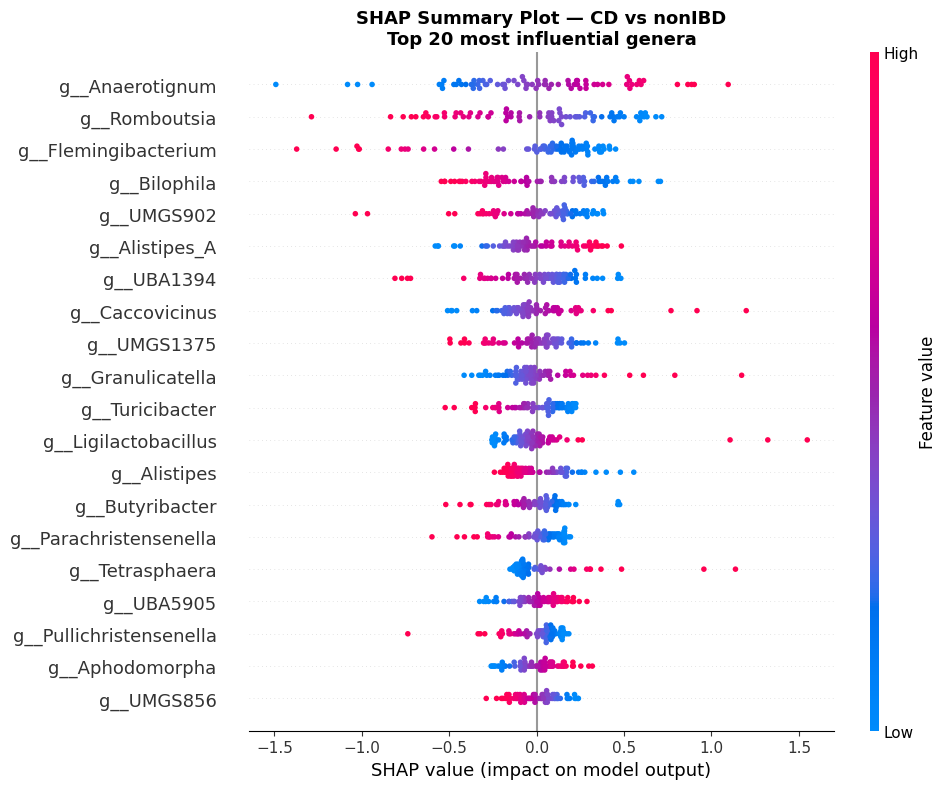

Saved: results/figures/21_shap_summary.png


In [13]:
# Clean genus names for plotting (keep only the genus part after last semicolon)
short_names = [g.split(";")[-1].strip() for g in top_features]
X_cd_display = X_cd_sel.copy()
X_cd_display.columns = short_names

explainer_display = shap.LinearExplainer(
    model, X_cd_display, feature_perturbation="interventional"
)
shap_values_display = explainer_display.shap_values(X_cd_display)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_display,
    X_cd_display,
    max_display=20,
    show=False,
    plot_size=None
)
plt.title("SHAP Summary Plot — CD vs nonIBD\n"
          "Top 20 most influential genera",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/figures/21_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/21_shap_summary.png")

## SHAP values bar plot

The following bar plots show which genera matter most overall. It is better for a quick ranking, while the plot above is better for biological interpretation.

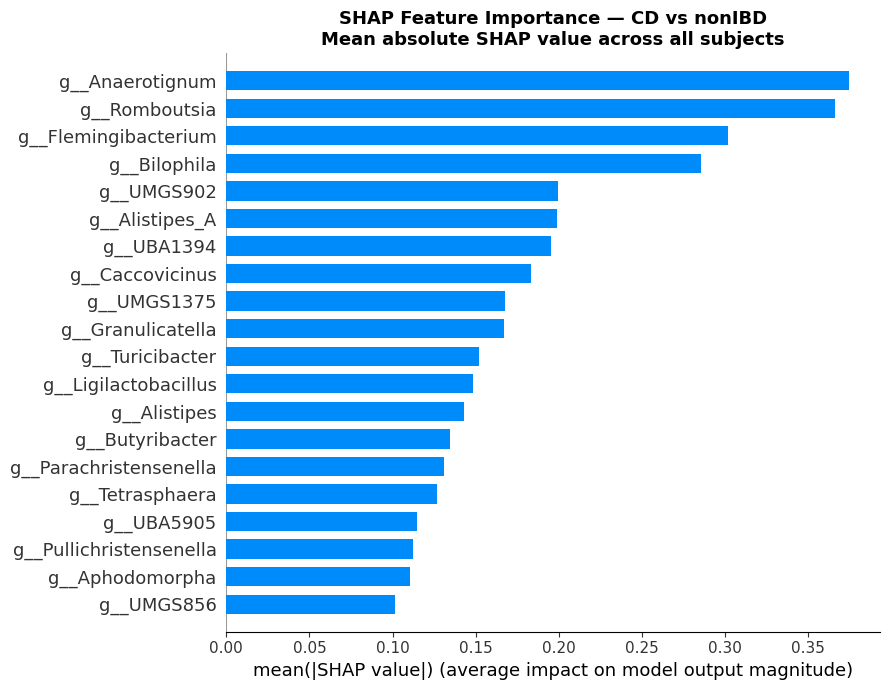

Saved: results/figures/22_shap_bar.png


In [14]:
plt.figure(figsize=(9, 7))
shap.summary_plot(
    shap_values_display,
    X_cd_display,
    plot_type="bar",
    max_display=20,
    show=False,
    plot_size=None
)
plt.title("SHAP Feature Importance — CD vs nonIBD\n"
          "Mean absolute SHAP value across all subjects",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/figures/22_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/22_shap_bar.png")

## Extract top SHAP genera in each direction

In [15]:
# Build a clean dataframe of top genera with direction
mean_shap_abs = np.abs(shap_values).mean(axis=0)
mean_shap_signed = shap_values.mean(axis=0)

shap_df = pd.DataFrame({
    "genus_full": top_features,
    "genus_short": short_names,
    "mean_abs_shap": mean_shap_abs,
    "mean_signed_shap": mean_shap_signed,
    "direction": ["CD" if s > 0 else "nonIBD" for s in mean_shap_signed],
    "mean_clr_cd": X_cd_sel[y_cd == 1].mean().values,
    "mean_clr_nonIBD": X_cd_sel[y_cd == 0].mean().values
}).sort_values("mean_abs_shap", ascending=False)

print("Top 15 genera by SHAP importance:")
print(shap_df.head(15)[
    ["genus_short", "mean_abs_shap", "direction",
     "mean_clr_cd", "mean_clr_nonIBD"]
].round(4).to_string(index=False))

# Save
shap_df.to_csv("../results/tables/shap_results_cd.csv", index=False)
print("\nSaved: results/tables/shap_results_cd.csv")

Top 15 genera by SHAP importance:
           genus_short  mean_abs_shap direction  mean_clr_cd  mean_clr_nonIBD
       g__Anaerotignum         0.3745    nonIBD       5.3739           4.3903
         g__Romboutsia         0.3662    nonIBD       1.1789           2.3295
  g__Flemingibacterium         0.3018        CD       0.1379           1.6144
          g__Bilophila         0.2858        CD       3.8203           5.4801
            g__UMGS902         0.1996    nonIBD       0.7033           1.7357
        g__Alistipes_A         0.1992    nonIBD       3.3719           4.5804
            g__UBA1394         0.1954        CD       1.9596           3.0816
       g__Caccovicinus         0.1832    nonIBD       1.8658           1.2724
           g__UMGS1375         0.1678        CD       2.6326           3.7821
     g__Granulicatella         0.1672        CD       1.4175           0.5472
       g__Turicibacter         0.1521    nonIBD       0.4086           1.6325
  g__Ligilactobacillus        

In [ ]:
# Check overlap between CD-discriminating genera and gender candidates
gender_genera = set(candidates["genus"].values)
shap_top20 = set(shap_df.head(20)["genus_full"].values)
shap_all = set(shap_df["genus_full"].values)

overlap_top20 = gender_genera & shap_top20
overlap_all = gender_genera & shap_all

print("=== Cross-reference: CD-SHAP genera vs Gender candidates ===")
print(f"Gender candidate genera: {len(gender_genera)}")
print(f"SHAP top 20 genera: {len(shap_top20)}")
print(f"SHAP all 100 genera: {len(shap_all)}")
print(f"\nOverlap with SHAP top 20: {len(overlap_top20)}")
print(f"Overlap with SHAP all 100: {len(overlap_all)}")

if len(overlap_all) > 0:
    print(f"\nOverlapping genera (CD-relevant AND gender-associated):")
    
    # Fix: filter and reset index to avoid column loss in merge
    shap_overlap = shap_df[shap_df["genus_full"].isin(overlap_all)][
        ["genus_full", "genus_short", "mean_abs_shap", "direction"]
    ].reset_index(drop=True)
    
    candidates_renamed = candidates[["genus", "rank_biserial"]].rename(
        columns={"genus": "genus_full"}
    ).reset_index(drop=True)
    
    overlap_df = shap_overlap.merge(candidates_renamed, on="genus_full", how="left")
    overlap_df["gender_direction"] = overlap_df["rank_biserial"].apply(
        lambda x: "↑ Male" if x > 0 else "↑ Female"
    )
    
    print(overlap_df[["genus_short", "mean_abs_shap",
                       "direction", "gender_direction",
                       "rank_biserial"]
                     ].round(4).to_string(index=False))
else:
    print("\nNo overlap found — CD signal and gender signal are independent.")

=== Cross-reference: CD-SHAP genera vs Gender candidates ===
Gender candidate genera: 82
SHAP top 20 genera: 20
SHAP all 100 genera: 100

Overlap with SHAP top 20: 1
Overlap with SHAP all 100: 1

Overlapping genera (CD-relevant AND gender-associated):


KeyError: 'genus_full'